In [1]:
!pip install simpy


In [2]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def bank_simulation(arrival_rate, service_rate):

    env = simpy.Environment()
    wait_times = []
    server = simpy.Resource(env, capacity=1)

    def customer(env):
        arrival_time = env.now

        with server.request() as request:
            yield request
            wait = env.now - arrival_time
            wait_times.append(wait)

            service_time = random.expovariate(service_rate)
            yield env.timeout(service_time)

    def customer_generator(env):
        while True:
            yield env.timeout(random.expovariate(arrival_rate))
            env.process(customer(env))

    env.process(customer_generator(env))
    env.run(until=100)

    return np.mean(wait_times)

In [4]:
data = []

for _ in range(1000):

    arrival_rate = random.uniform(0.5, 2.0)
    service_rate = random.uniform(1.0, 3.0)

    avg_wait = bank_simulation(arrival_rate, service_rate)

    data.append([arrival_rate, service_rate, avg_wait])

df = pd.DataFrame(data, columns=["arrival_rate", "service_rate", "avg_waiting_time"])

df.head()

,arrival_rate,service_rate,avg_waiting_time
0,1.765459,1.643289,13.147737
1,1.224950,2.349215,0.393040
2,0.863999,2.337579,0.139833
3,1.660832,1.808805,2.595628
4,0.992283,2.702689,0.382414


In [5]:
from sklearn.model_selection import train_test_split

X = df[["arrival_rate", "service_rate"]]
y = df["avg_waiting_time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append([name, mse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2 Score"])
results_df

,Model,MSE,R2 Score
0,Linear Regression,15.263416,0.482527
1,Decision Tree,7.490209,0.746061
2,Random Forest,5.975098,0.797427
3,Gradient Boosting,6.556162,0.777728
4,KNN,5.918241,0.799355
5,SVR,5.892231,0.800237


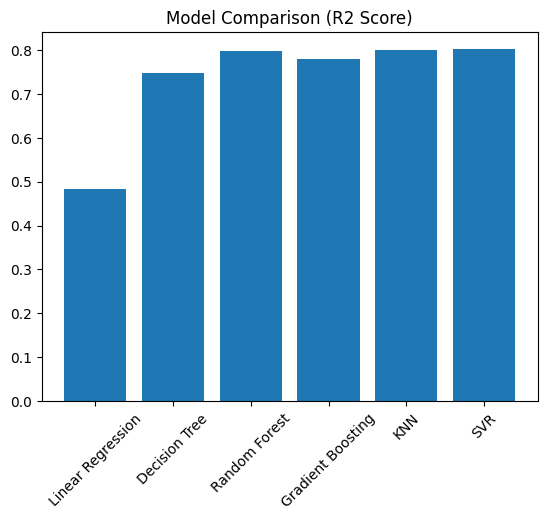

In [8]:
plt.figure()
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.show()

In [9]:
best_model = results_df.sort_values(by="R2 Score", ascending=False)
best_model.head(1)

,Model,MSE,R2 Score
5,SVR,5.892231,0.800237
